#  PART B Netflix DATA Analysis

## Problem Statement
The Netflix Movies & TV Shows dataset is analyzed in this notebook to see whether the ratings distribution of movies and TV shows varies and how the Netflix colelction has expanded over time.


## Questions I am investigating

1. How has the number of titles added to Netflix changed over time based on the year added?
2. Do Movies and TV Shows differ in ratings distribution?

These questions help understand Netflix’s content growth over time and differences between Movies and TV Shows.


## Dataset downloaded from Kaggle Netflix Titles dataset.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Dictionary (key columns used)

- **show_id**: Unique identifier for each title
- **type**: Movie or TV Show
- **title**: Title name
- **country**: Country/countries of production 
- **date_added**: Date when the title was added
- **release_year**: Year the title was  released
- **rating**: Content rating (e.g., PG-13, TV-MA)
- **duration**: Runtime in minutes (Movies) or number of seasons (TV Shows)
- **listed_in**: Categories/genres 


In [17]:
df.shape, df.columns.tolist()


((8807, 12),
 ['show_id',
  'type',
  'title',
  'director',
  'cast',
  'country',
  'date_added',
  'release_year',
  'rating',
  'duration',
  'listed_in',
  'description'])

In [18]:
# Remove duplicate rows
df = df.drop_duplicates()

#  Convert date_added to datetime (invalid parses become NaT)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

#  Create year_added for trend analysis
df["year_added"] = df["date_added"].dt.year

# Checking whether any key is missing
df[["type", "country", "date_added", "year_added", "rating", "duration", "release_year"]].isna().sum()


type              0
country         831
date_added       98
year_added       98
rating            4
duration          3
release_year      0
dtype: int64

## Missing values in country and date_added handled using dropna().


## Custom Function
A helper function  is used to split comma-separated columns like country into individual values.

In [19]:
def clean_split_column(series, sep=","):
    return (
        series.dropna()
              .astype(str)
              .str.split(sep)
              .explode()
              .str.strip()
              .replace("", np.nan)
              .dropna()
    )


In [20]:
# Testing a helper function
countries = clean_split_column(df["country"])
countries.value_counts().head(10)


country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

## B2 Analysis
## Analysis 1: Trend over time: titles per year (e.g., using release year or parsing date added)

In [21]:
titles_per_year = (
    df.dropna(subset=["year_added"])
      .groupby("year_added")
      .size()
      .reset_index(name="titles_added")
      .sort_values("year_added")
)

titles_per_year.tail()


,year_added,titles_added
9,2017.0,1164
10,2018.0,1625
11,2019.0,1999
12,2020.0,1878
13,2021.0,1498


## Analysis 2: Distribution/outliers: analyze distributions of duration (after cleaning) or release years, and identify potential outliers.

In [22]:
old_titles = df[df["release_year"] < 2000]
old_titles[["title", "release_year"]].head()


,title,release_year
7,Sankofa,1993
22,Avvai Shanmughi,1996
24,Jeans,1998
26,Minsara Kanavu,1997
41,Jaws,1975


## B3: Visualization


## Distribution Plot

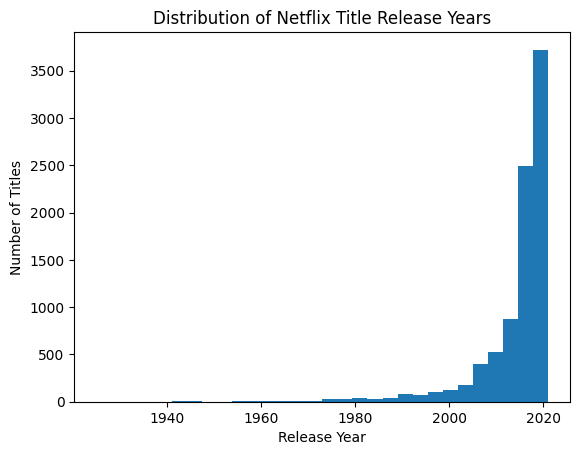

In [23]:
plt.figure()
plt.hist(df["release_year"], bins=30)
plt.title("Distribution of Netflix Title Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


**Interpretation:**
 The majority of Netflix's titles were published after 2000, indicating that the majority of its material is contemporary. There are a few titles from previous decades that might be older productions or legendary movies.
When compared to the bulk of the dataset, these earlier titles may be regarded as possible outliers.

## Relationship Plot


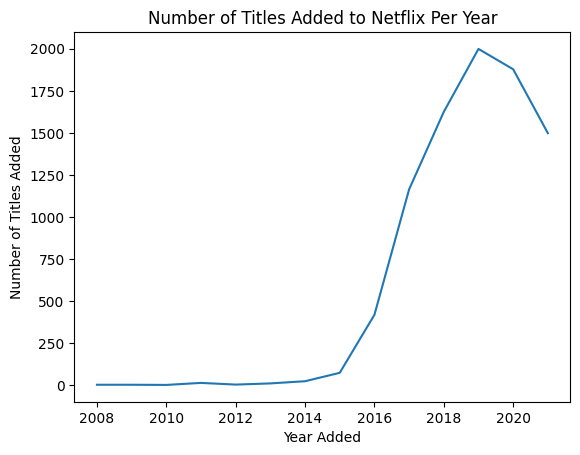

In [24]:
titles_per_year = (
    df.dropna(subset=["year_added"])
      .assign(year_added=lambda d: d["year_added"].astype(int))
      .groupby("year_added")
      .size()
      .reset_index(name="titles_added")
      .sort_values("year_added")
)

plt.figure()
plt.plot(titles_per_year["year_added"], titles_per_year["titles_added"])
plt.title("Number of Titles Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.show()



**Interpretation:**  
Netflix's content catalog has grown over time, as evidenced by the amount of titles that have been added. There are observable peaks in some years, which might correspond to times when Netflix added more content or grew quickly. This pattern suggests that Netflix's titles has expanded over time.